In [1]:
import sys
sys.path.insert(0, "..")

import joblib

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from loguru import logger

pd.set_option("display.max_columns", None)

In [2]:
from src.evaluation.metrics import build_predictions_report

In [3]:
def plot_barh_by_model(results_df, x, y="model", hue=None, title="", figsize=(8, 6)):
    """Barplot horizontal genérico para comparar modelos por una métrica."""
    df_sorted = results_df.sort_values(x, ascending=True)
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(df_sorted, x=x, y=y, hue=hue, order=df_sorted[y], ax=ax)
    ax.set_title(title, loc="left", pad=20)
    ax.set_xlabel("")
    ax.set_ylabel("")
    sns.despine()
    if hue:
        ax.legend(title=hue, loc="upper right")
    plt.tight_layout()
    plt.show()

In [4]:
LEVEL = 'level_09_daily_store_dept'

In [6]:
import joblib

artifact_path = f"../artifacts/models/{LEVEL}_artifact.pkl"
artifact = joblib.load(artifact_path)

model = artifact["model"]
X_test, y_test = artifact["X_test"], artifact["y_test"]
FEATURES = artifact["features"]
feature_importance = artifact["feature_importance"]
results_df = artifact["results_df"]

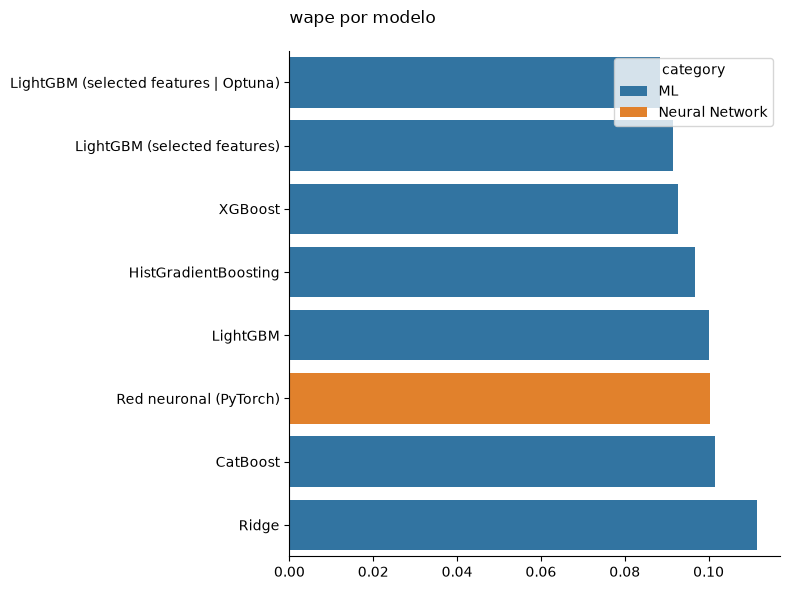

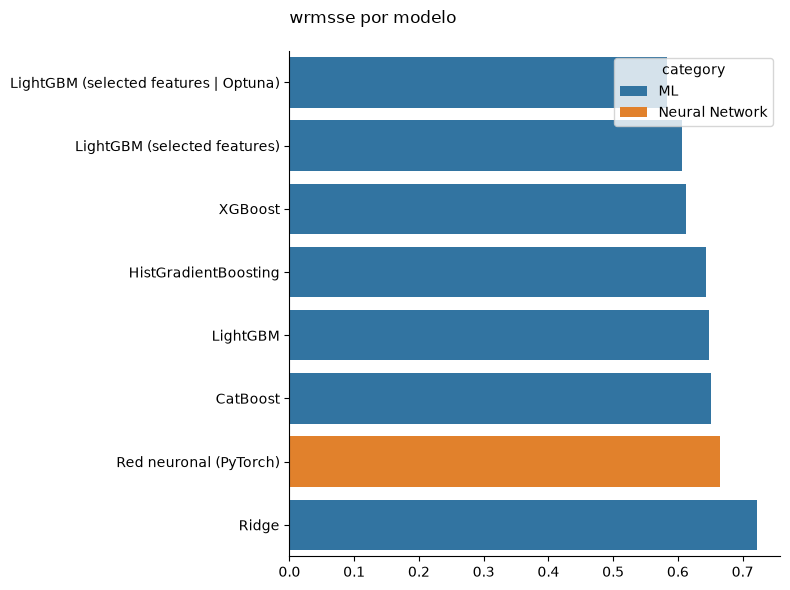

In [7]:
#['wape', 'wrmsse', 'mae', 'rmse', 'mape', 'smape', 'bias', 'rmsle', 'tracking_signal', 'spec', 'mase', 'fit_time']:
for col in ['wape', 'wrmsse',]:
    plot_barh_by_model(results_df, hue="category", x=col, y="model", title=f"{col} por modelo")

## Explicación modelo

In [8]:
import shap

explainer = shap.TreeExplainer(model)

X_shap = X_test.sample(n=min(2000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_shap)

In [9]:
shap_df = pd.DataFrame(shap_values, columns=X_shap.columns, index=X_shap.index)

importance_df = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

print(importance_df)

                           feature  mean_abs_shap
29                            lag1     173.703859
32                            lag7      97.932617
35                           lag28      43.067444
42  rolling_mean_lag7_window_size7      33.639920
7                             snap      18.914767
..                             ...            ...
10                      weekofyear       0.482757
20                       month_sin       0.349442
21                       month_cos       0.273488
15                 days_to_closure       0.172546
27                     pct_zero_28       0.055214

[63 rows x 2 columns]


### Importancia global de features

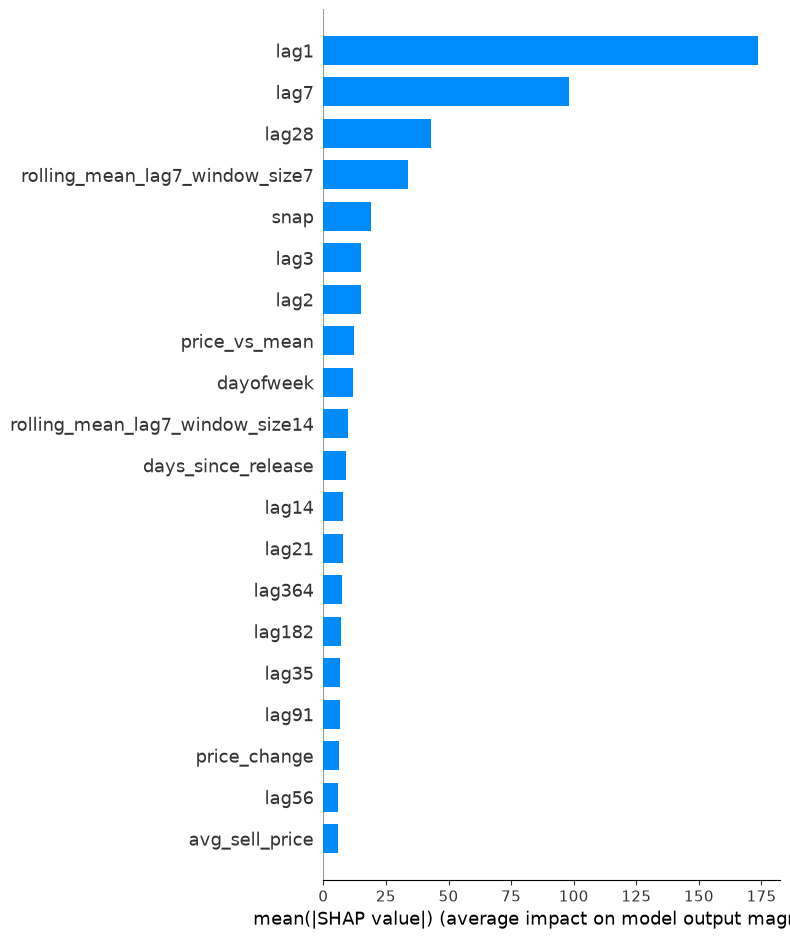

In [10]:
shap.summary_plot(shap_values, X_shap, plot_type="bar")

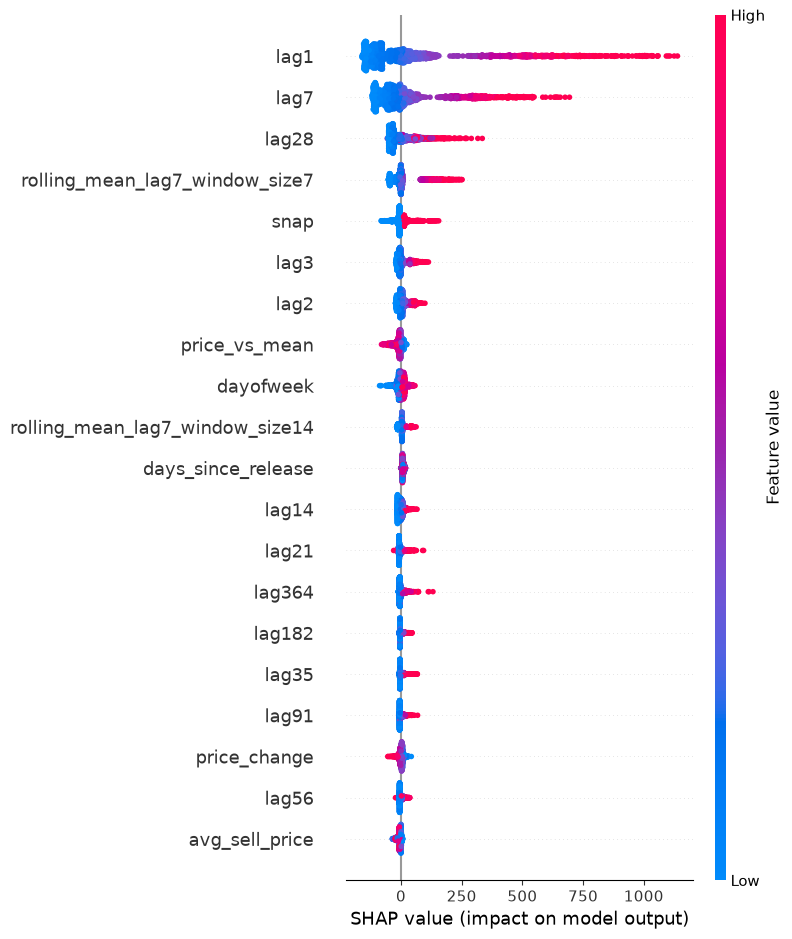

In [11]:
shap.summary_plot(shap_values, X_shap)

### Dependencia por feature

Feature más importante: lag1


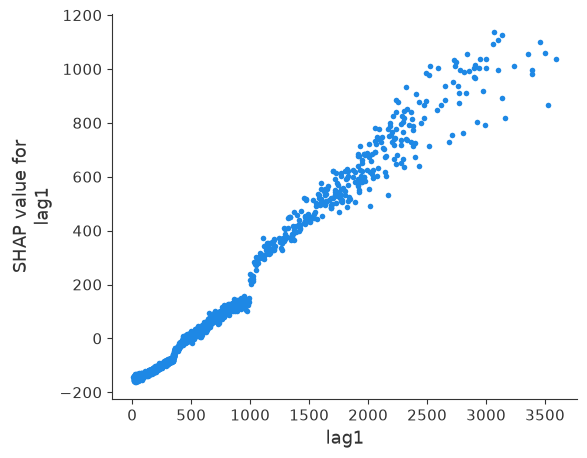

In [12]:
top_feature = X_shap.columns[np.argsort(-np.abs(shap_values).mean(axis=0))[0]]
print(f"Feature más importante: {top_feature}")

shap.dependence_plot(top_feature, shap_values, X_shap, interaction_index=None)

In [13]:
metrics_test_final, df_pred = build_predictions_report(artifact['train'], artifact['test'], y_test, model.predict(X_test), target_col=artifact['target'])

print(f"Test WAPE: {metrics_test_final['wape']:.2%}")
print(f"Test WRMSSE: {metrics_test_final['wrmsse']:.4f}")

Test WAPE: 8.68%
Test WRMSSE: 0.6159


# Predicciones

In [14]:
from src.evaluation import analizar_prediccion as _analizar_prediccion

def analizar_prediccion(agg_id, test=artifact['test'], target=artifact['target'],
                         explainer=explainer, date=None, max_display=10):
    return _analizar_prediccion(
        test, X_test, df_pred, target, agg_id,
        date=date, max_display=max_display, explainer=explainer,
    )

In [15]:
from src.evaluation.metrics import build_series_metrics

df_metrics = build_series_metrics(artifact['train'], df_pred, target_col=artifact['target'], weight_level=["date"])
df_metrics.head(10)

,n_days,n_days_with_sales,sales,y_pred,error,abs_error,gross_sales,gross_sales_pct,wape,bias,rmsle,tracking_signal,wrmsse,mase,spec
agg_id,,,,,,,,,,,,,,,
FOODS_3_FOODS_CA_3_CA,28,28,77367.0,78179.0,-812.0,4816.0,194847.031250,0.049948,0.062249,0.010495,0.075883,-4.720930,0.441095,0.460869,219.776786
FOODS_3_FOODS_CA_1_CA,28,28,65999.0,64024.0,1975.0,3345.0,167972.828125,0.043059,0.050683,-0.029925,0.069271,16.532138,0.413067,0.326527,629.339286
HOUSEHOLD_1_HOUSEHOLD_CA_3_CA,28,28,38478.0,39723.0,-1245.0,2369.0,163889.625000,0.042012,0.061568,0.032356,0.084983,-14.715070,0.501028,0.549369,140.866071
FOODS_3_FOODS_WI_2_WI,28,28,67991.0,64362.0,3629.0,5415.0,154892.234375,0.039706,0.079643,-0.053375,0.104361,18.764912,0.847796,0.679848,1770.241071
FOODS_3_FOODS_CA_2_CA,28,28,57132.0,54301.0,2831.0,4325.0,146760.937500,0.037622,0.075702,-0.049552,0.087712,18.327861,0.796746,0.730708,798.375000
FOODS_3_FOODS_TX_2_TX,28,28,56187.0,55127.0,1060.0,3508.0,135407.515625,0.034711,0.062434,-0.018866,0.080266,8.460661,0.422302,0.387054,267.696429
FOODS_3_FOODS_TX_3_TX,28,28,53508.0,50920.0,2588.0,4470.0,131170.312500,0.033625,0.083539,-0.048367,0.098836,16.211186,0.643756,0.659348,1011.080357
FOODS_3_FOODS_WI_3_WI,28,28,58230.0,58347.0,-117.0,3255.0,130090.851562,0.033348,0.055899,0.002009,0.069783,-1.006452,0.386497,0.350011,107.946429
FOODS_3_FOODS_WI_1_WI,28,28,49939.0,49213.0,726.0,2852.0,121677.796875,0.031192,0.057110,-0.014538,0.063418,7.127630,0.387052,0.461913,328.982143


In [16]:
df_metrics.head(10)

,n_days,n_days_with_sales,sales,y_pred,error,abs_error,gross_sales,gross_sales_pct,wape,bias,rmsle,tracking_signal,wrmsse,mase,spec
agg_id,,,,,,,,,,,,,,,
FOODS_3_FOODS_CA_3_CA,28,28,77367.0,78179.0,-812.0,4816.0,194847.031250,0.049948,0.062249,0.010495,0.075883,-4.720930,0.441095,0.460869,219.776786
FOODS_3_FOODS_CA_1_CA,28,28,65999.0,64024.0,1975.0,3345.0,167972.828125,0.043059,0.050683,-0.029925,0.069271,16.532138,0.413067,0.326527,629.339286
HOUSEHOLD_1_HOUSEHOLD_CA_3_CA,28,28,38478.0,39723.0,-1245.0,2369.0,163889.625000,0.042012,0.061568,0.032356,0.084983,-14.715070,0.501028,0.549369,140.866071
FOODS_3_FOODS_WI_2_WI,28,28,67991.0,64362.0,3629.0,5415.0,154892.234375,0.039706,0.079643,-0.053375,0.104361,18.764912,0.847796,0.679848,1770.241071
FOODS_3_FOODS_CA_2_CA,28,28,57132.0,54301.0,2831.0,4325.0,146760.937500,0.037622,0.075702,-0.049552,0.087712,18.327861,0.796746,0.730708,798.375000
FOODS_3_FOODS_TX_2_TX,28,28,56187.0,55127.0,1060.0,3508.0,135407.515625,0.034711,0.062434,-0.018866,0.080266,8.460661,0.422302,0.387054,267.696429
FOODS_3_FOODS_TX_3_TX,28,28,53508.0,50920.0,2588.0,4470.0,131170.312500,0.033625,0.083539,-0.048367,0.098836,16.211186,0.643756,0.659348,1011.080357
FOODS_3_FOODS_WI_3_WI,28,28,58230.0,58347.0,-117.0,3255.0,130090.851562,0.033348,0.055899,0.002009,0.069783,-1.006452,0.386497,0.350011,107.946429
FOODS_3_FOODS_WI_1_WI,28,28,49939.0,49213.0,726.0,2852.0,121677.796875,0.031192,0.057110,-0.014538,0.063418,7.127630,0.387052,0.461913,328.982143


In [17]:
df_pred.query('agg_id == "FOODS_3_FOODS_CA_3_CA"').nlargest(10, 'wape')

,agg_id,date,sales,gross_sales,y_pred,error,abs_error,wape,bias
44615,FOODS_3_FOODS_CA_3_CA,2016-04-25,2972.0,7675.609863,2512.0,460.0,460.0,0.154778,-0.154778
44632,FOODS_3_FOODS_CA_3_CA,2016-05-12,2202.0,5538.709961,2511.0,-309.0,309.0,0.140327,0.140327
44616,FOODS_3_FOODS_CA_3_CA,2016-04-26,2240.0,5626.109863,2524.0,-284.0,284.0,0.126786,0.126786
44642,FOODS_3_FOODS_CA_3_CA,2016-05-22,3573.0,8930.370117,3157.0,416.0,416.0,0.116429,-0.116429
44618,FOODS_3_FOODS_CA_3_CA,2016-04-28,2209.0,5390.859863,2460.0,-251.0,251.0,0.113626,0.113626
44636,FOODS_3_FOODS_CA_3_CA,2016-05-16,2615.0,6564.209961,2902.0,-287.0,287.0,0.109751,0.109751
44629,FOODS_3_FOODS_CA_3_CA,2016-05-09,3238.0,8316.910156,2888.0,350.0,350.0,0.108091,-0.108091
44635,FOODS_3_FOODS_CA_3_CA,2016-05-15,3496.0,8896.730469,3160.0,336.0,336.0,0.096110,-0.096110
44628,FOODS_3_FOODS_CA_3_CA,2016-05-08,3001.0,7765.770020,3271.0,-270.0,270.0,0.089970,0.089970
44623,FOODS_3_FOODS_CA_3_CA,2016-05-03,2655.0,6551.040039,2869.0,-214.0,214.0,0.080603,0.080603


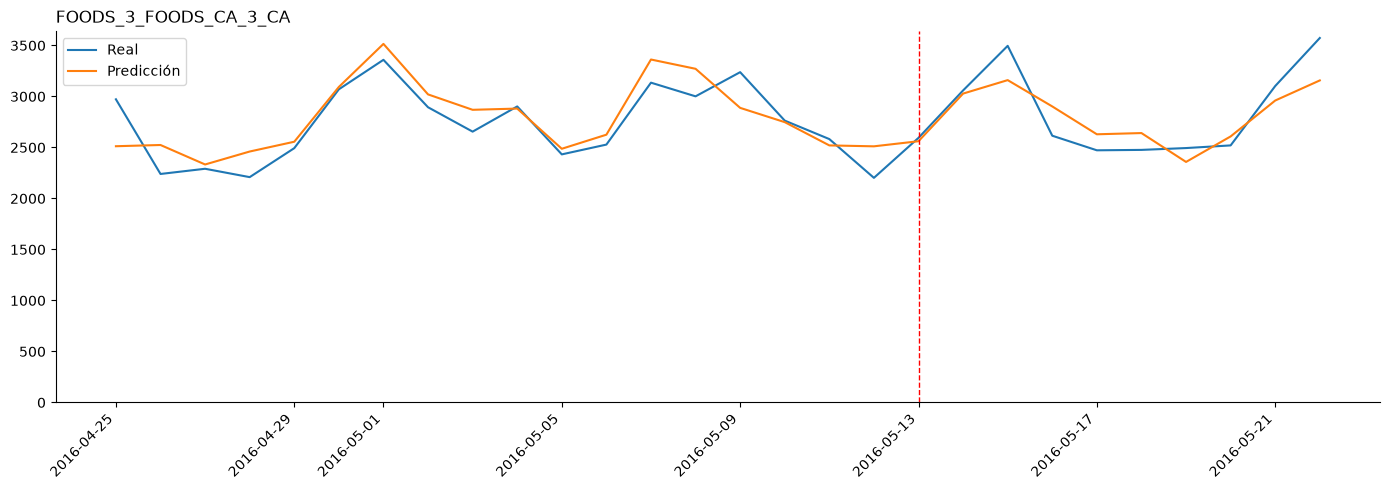

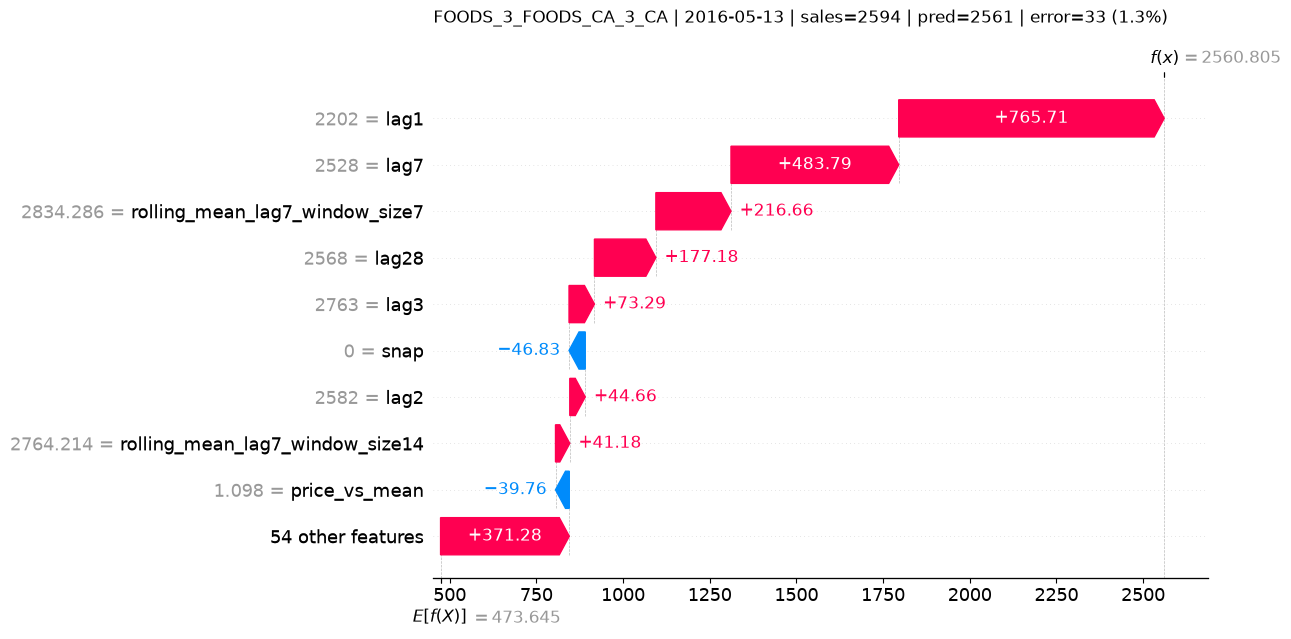

In [18]:
analizar_prediccion(agg_id='FOODS_3_FOODS_CA_3_CA', date='2016-05-13' )